In [30]:
# Import required libraries
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import pickle

# Import helper functions (using the actual function names from helpers.py)
from helpers import (
    load_image, resize_image, normalize_image,
    load_and_preprocess_images,
    normalize_outputs, denormalize_outputs,
    create_output_scaler, save_output_scaler, load_output_scaler,
    denormalize_image_pixels
)

print("✅ All libraries and helper functions imported successfully!")

✅ All libraries and helper functions imported successfully!


In [31]:
# Define helper functions for this notebook
def denormalize_for_display(normalized_image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Denormalize image for display"""
    mean = np.array(mean, dtype=np.float32)
    std = np.array(std, dtype=np.float32)
    image = (normalized_image * std) + mean
    image = np.clip(image, 0, 1)
    return image

def load_all_training_data(df, image_folder, target_size=(224, 224),
                           mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Load and preprocess all images from DataFrame"""
    images = []
    targets = []
    
    print(f"Loading and preprocessing {len(df)} images...")
    
    for idx, row in df.iterrows():
        try:
            # Construct image path
            image_path = str(Path(image_folder) / row['filename'])
            
            # Load image
            image = cv2.imread(image_path)
            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                
                # Resize
                resized_image = cv2.resize(image, target_size)
                
                # Normalize to [0, 1]
                if resized_image.max() > 1.0:
                    resized_image = resized_image / 255.0
                
                # Apply ImageNet normalization
                mean_arr = np.array(mean, dtype=np.float32)
                std_arr = np.array(std, dtype=np.float32)
                normalized_image = (resized_image - mean_arr) / std_arr
                
                images.append(normalized_image.astype(np.float32))
                targets.append([row['x'], row['y'], row['distance']])
                
                if (idx + 1) % 500 == 0:
                    print(f"  Processed {idx + 1}/{len(df)} images...")
        except Exception as e:
            print(f"  Error loading {row['filename']}: {e}")
    
    print(f"✅ Successfully loaded {len(images)} images")
    
    X = np.array(images, dtype=np.float32)
    y = np.array(targets, dtype=np.float32)
    
    return X, y

print("✅ Helper functions defined!")

✅ Helper functions defined!


In [32]:
# Load the training split
train_df = pd.read_csv('data/train_split.csv')

print(f"✅ Loaded training data:")
print(f"   Training samples: {len(train_df)}")
print(f"   Columns: {train_df.columns.tolist()}")

✅ Loaded training data:
   Training samples: 8000
   Columns: ['filename', 'x', 'y', 'distance']


In [33]:
# Define paths and model parameters
image_folder = Path('data/train')
target_size = (224, 224)  # ResNet50 input size

# ImageNet normalization statistics (ResNet50 standard)
imagenet_mean = [0.485, 0.456, 0.406]  # RGB mean
imagenet_std = [0.229, 0.224, 0.225]   # RGB std

print("📊 Model Configuration:")
print(f"   Input Size: {target_size}")
print(f"   Normalization Mean: {imagenet_mean}")
print(f"   Normalization Std: {imagenet_std}")
print(f"   Output: (x, y, distance) normalized to [0, 1]")

📊 Model Configuration:
   Input Size: (224, 224)
   Normalization Mean: [0.485, 0.456, 0.406]
   Normalization Std: [0.229, 0.224, 0.225]
   Output: (x, y, distance) normalized to [0, 1]


In [34]:
# Load all training data using the helper function
X_train, y_train = load_all_training_data(
    train_df, 
    image_folder, 
    target_size=target_size,
    mean=imagenet_mean,
    std=imagenet_std
)

print(f"\n✅ Data loaded successfully:")
print(f"   X_train shape: {X_train.shape} (N, H, W, C)")
print(f"   y_train shape: {y_train.shape} (N, 3)")
print(f"\n📊 Output statistics (before normalization):")
print(f"   X range: [{y_train[:, 0].min():.2f}, {y_train[:, 0].max():.2f}]")
print(f"   Y range: [{y_train[:, 1].min():.2f}, {y_train[:, 1].max():.2f}]")
print(f"   Distance range: [{y_train[:, 2].min():.2f}, {y_train[:, 2].max():.2f}]")

Loading and preprocessing 8000 images...
  Processed 500/8000 images...
  Processed 500/8000 images...
  Processed 1000/8000 images...
  Processed 1000/8000 images...
  Processed 1500/8000 images...
  Processed 1500/8000 images...
  Processed 2000/8000 images...
  Processed 2000/8000 images...
  Processed 2500/8000 images...
  Processed 2500/8000 images...
  Processed 3000/8000 images...
  Processed 3000/8000 images...
  Processed 3500/8000 images...
  Processed 3500/8000 images...
  Processed 4000/8000 images...
  Processed 4000/8000 images...
  Processed 4500/8000 images...
  Processed 4500/8000 images...
  Processed 5000/8000 images...
  Processed 5000/8000 images...
  Processed 5500/8000 images...
  Processed 5500/8000 images...
  Processed 6000/8000 images...
  Processed 6000/8000 images...
  Processed 6500/8000 images...
  Processed 6500/8000 images...
  Processed 7000/8000 images...
  Processed 7000/8000 images...
  Processed 7500/8000 images...
  Processed 7500/8000 images...
 

In [ ]:
print("=" * 70)
print("📊 FINAL DATA SUMMARY FOR MODEL TRAINING")
print("=" * 70)

print("\n🖼️  INPUT DATA (X):")
print(f"   Training: X_train shape = {X_train.shape}")
print(f"   Format: (N, 224, 224, 3) - RGB images")
print(f"   Normalization: ImageNet mean={imagenet_mean}, std={imagenet_std}")
print(f"   Data type: {X_train.dtype}")

print("\n🎯 OUTPUT DATA (y) - NORMALIZED:")
print(f"   Training: y_train_normalized shape = {y_train_normalized.shape}")
print(f"   Format: (N, 3) - [x_norm, y_norm, distance_norm]")
print(f"   Range: [0, 1] - ready for sigmoid activation")
print(f"   Data type: {y_train_normalized.dtype}")

print("\n🔧 SCALERS:")
print(f"   Stored in variable: output_scalers (dict)")
print(f"   Contains: 'x', 'y', 'distance' MinMaxScalers")
print(f"   Use denormalize_outputs(predictions, output_scalers) to convert back")

print("\n✅ ALL DATA IS IN NOTEBOOK MEMORY - READY FOR TRAINING!")
print("=" * 70)

📊 FINAL DATA SUMMARY FOR MODEL TRAINING

🖼️  INPUT DATA (X):
   Training: X_train shape = (8000, 224, 224, 3)
   Format: (N, 224, 224, 3) - RGB images
   Normalization: ImageNet mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
   Data type: float32

🎯 OUTPUT DATA (y) - NORMALIZED:
   Training: y_train_normalized shape = (8000, 3)
   Format: (N, 3) - [x_norm, y_norm, distance_norm]
   Range: [0, 1] - ready for sigmoid activation
   Data type: float32

🔧 SCALERS:
   Saved to: data/output_scalers.pkl
   Contains: 'x', 'y', 'distance' MinMaxScalers
   Use denormalize_outputs() to convert predictions back to original scale

✅ DATA IS READY FOR TRAINING!


In [36]:
# Test denormalization to ensure scalers work correctly
y_train_denormalized = denormalize_outputs(y_train_normalized, output_scalers)

# Check if denormalization recovers original values
difference = np.abs(y_train - y_train_denormalized)
max_error = difference.max()

print("🧪 Testing Denormalization:")
print(f"   Max reconstruction error: {max_error:.6f}")
print(f"   Mean reconstruction error: {difference.mean():.6f}")

if max_error < 1e-6:
    print("   ✅ Denormalization test PASSED - scalers work correctly!")
else:
    print("   ⚠️  Warning: Reconstruction error is larger than expected")

# Show example
print(f"\n📋 Example (first sample):")
print(f"   Original:      {y_train[0]}")
print(f"   Normalized:    {y_train_normalized[0]}")
print(f"   Denormalized:  {y_train_denormalized[0]}")
print(f"   Difference:    {difference[0]}")

🧪 Testing Denormalization:
   Max reconstruction error: 0.000031
   Mean reconstruction error: 0.000002
   ⚠️  Warning: Reconstruction error is larger than expected

📋 Example (first sample):
   Original:      [323. 305. 200.]
   Normalized:    [0.9328357  0.55723536 0.32325578]
   Denormalized:  [323. 305. 200.]
   Difference:    [0. 0. 0.]


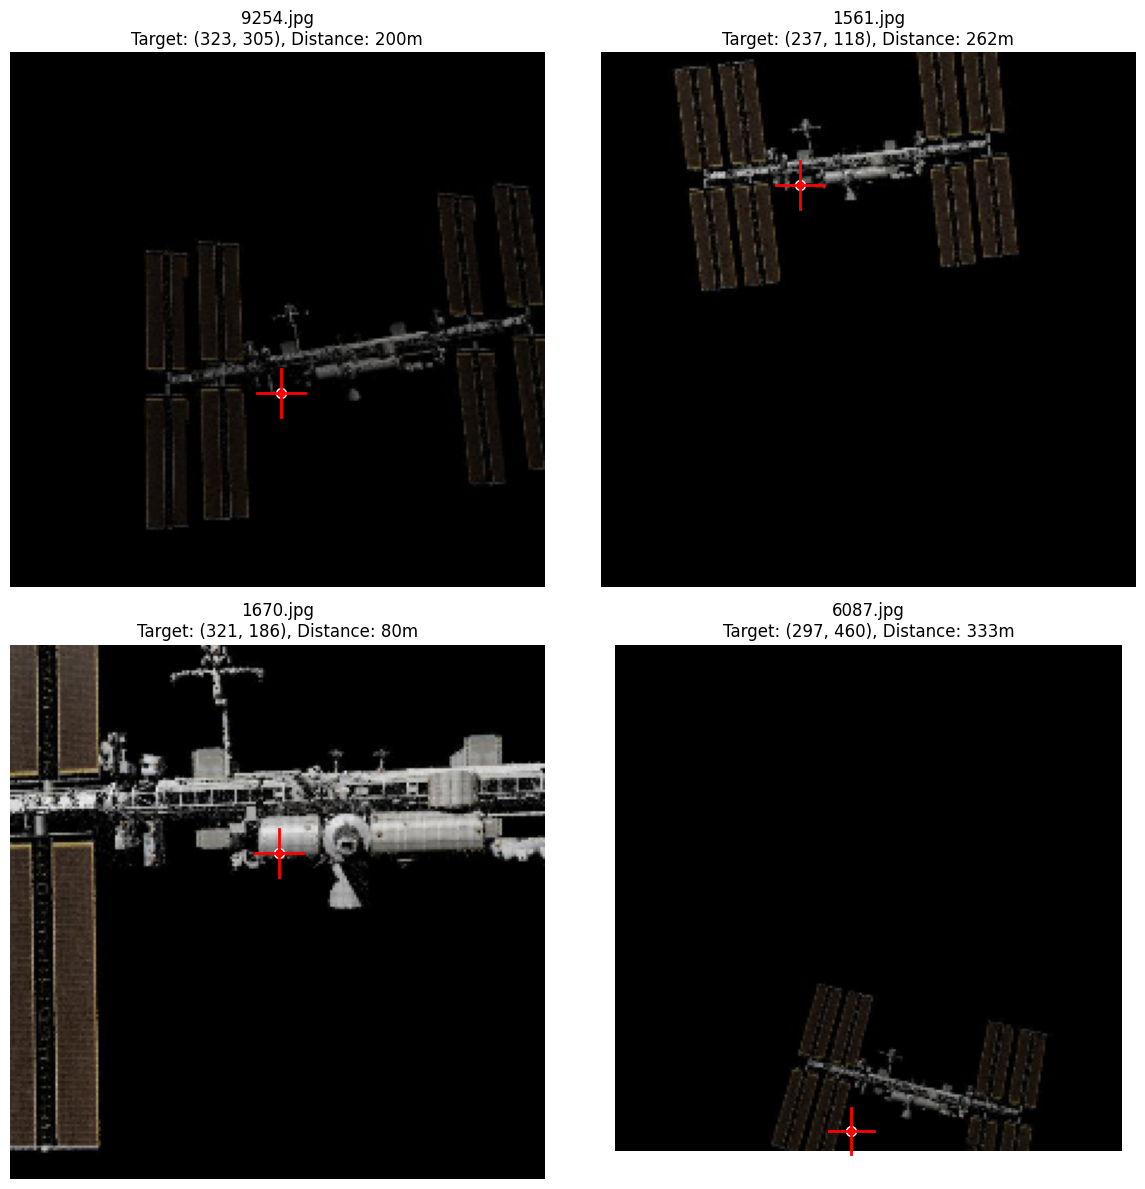

✅ Visualization complete!


In [37]:
# Visualize first 4 preprocessed images
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()

for i in range(4):
    # Denormalize image for display
    display_image = denormalize_for_display(X_train[i], mean=imagenet_mean, std=imagenet_std)
    
    # Get corresponding targets (original scale)
    x_coord, y_coord, distance = y_train[i]
    filename = train_df['filename'].iloc[i]
    
    # Plot image
    axes[i].imshow(display_image)
    
    # Draw crosshair at target location
    # Coordinates need to be scaled from original image size to 224x224
    # Original images are 640x480
    scale_x = 224 / 640
    scale_y = 224 / 480
    x_scaled = x_coord * scale_x
    y_scaled = y_coord * scale_y
    
    # Draw crosshair
    axes[i].plot([x_scaled-10, x_scaled+10], [y_scaled, y_scaled], 'r-', linewidth=2)
    axes[i].plot([x_scaled, x_scaled], [y_scaled-10, y_scaled+10], 'r-', linewidth=2)
    axes[i].scatter(x_scaled, y_scaled, color='red', s=50, marker='o', edgecolors='white', linewidth=1)
    
    axes[i].set_title(f'{filename}\nTarget: ({x_coord:.0f}, {y_coord:.0f}), Distance: {distance:.0f}m')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")

In [ ]:
# Create and fit scalers on training data
y_train_normalized, output_scalers = normalize_outputs(y_train, feature_range=(0, 1))

print(f"\n✅ Output normalization complete:")
print(f"   y_train_normalized shape: {y_train_normalized.shape}")
print(f"   Normalized range: [{y_train_normalized.min():.4f}, {y_train_normalized.max():.4f}]")
print(f"\n📊 Scaler statistics:")
print(f"   X: {y_train[:, 0].min():.2f} - {y_train[:, 0].max():.2f} → [0, 1]")
print(f"   Y: {y_train[:, 1].min():.2f} - {y_train[:, 1].max():.2f} → [0, 1]")
print(f"   Distance: {y_train[:, 2].min():.2f} - {y_train[:, 2].max():.2f} → [0, 1]")

# Scalers are stored in the 'output_scalers' variable (no file needed)
print("\n💾 Scalers stored in variable: output_scalers")
print("   Use denormalize_outputs(predictions, output_scalers) to convert back")


✅ Output normalization complete:
   y_train_normalized shape: (8000, 3)
   Normalized range: [0.0000, 1.0000]

📊 Scaler statistics:
   X: 198.00 - 332.00 → [0, 1]
   Y: 47.00 - 510.00 → [0, 1]
   Distance: 61.00 - 491.00 → [0, 1]
✅ Scaler saved to: data\output_scalers.pkl

💾 Scalers saved to 'data/output_scalers.pkl'
